In [22]:
packages = [
    "numpy",
    "pandas",
    "sklearn",
    "matplotlib",
    "seaborn",
    "scipy",
    "torch",
    "torchvision",
    "tensorflow",
    "fastapi"
]

for pkg in packages:
    try:
        __import__(pkg)
        print(f"{pkg} ✅ installed")
    except ImportError:
        print(f"{pkg} ❌ NOT installed")



import torch
import tensorflow as tf

def print_hardware() -> None:
    print("\n--- Hardware backends ---")
    print(f"torch CUDA available : {torch.cuda.is_available()}")
    print(f"torch MPS  available : {torch.backends.mps.is_available()}")  # Apple Silicon GPU
    print(f"tensorflow devices   : {[d.device_type for d in tf.config.list_physical_devices()]}")

print_hardware()


print(f"tensorflow {tf.__version__}")

numpy ✅ installed
pandas ✅ installed
sklearn ✅ installed
matplotlib ✅ installed
seaborn ✅ installed
scipy ✅ installed
torch ❌ NOT installed
torchvision ❌ NOT installed
tensorflow ❌ NOT installed
fastapi ✅ installed


ModuleNotFoundError: No module named 'torch'

In [ ]:
np.set_printoptions(precision=4, suppress=True, linewidth=110)

ROW_NAMES = ['A', 'B', 'C', 'D', 'E']
FEATURE_NAMES = ['age', 'salary']
HIDDEN_NAMES = ['wealth', 'maturity', 'urgency']

def relu(z):       return np.maximum(0, z)
def relu_grad(z):  return (z > 0).astype(float)
def sigmoid(z):    return 1.0 / (1.0 + np.exp(-z))

def bce(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

NameError: name 'np' is not defined

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
#helper function
np.set_printoptions(precision=4, suppress=True, linewidth=110)

ROW_NAMES = ['A', 'B', 'C', 'D', 'E']
FEATURE_NAMES = ['age', 'salary']
HIDDEN_NAMES = ['wealth', 'maturity', 'urgency']

def relu(z):       return np.maximum(0, z)
def relu_grad(z):  return (z > 0).astype(float)
def sigmoid(z):    return 1.0 / (1.0 + np.exp(-z))

def bce(y, p, eps=1e-12):
    p = np.clip(p, eps, 1 - eps)
    return -np.mean(y * np.log(p) + (1 - y) * np.log(1 - p))

In [ ]:
X = np.array([
    [0.25, 0.30],   # A: young, low salary       -> no buy
    [0.30, 0.50],   # B: young, medium salary    -> buy
    [0.40, 0.80],   # C: middle-age, high salary -> buy
    [0.55, 0.35],   # D: older, modest salary    -> no buy
    [0.60, 1.00],   # E: older, top salary       -> buy
])
y = np.array([[0], [1], [1], [0], [1]], dtype=float)

df = pd.DataFrame(np.hstack([X, y]), index=ROW_NAMES, columns=['age', 'salary', 'buy'])
df['buy'] = df['buy'].astype(int)
df

,age,salary,buy
A,0.25,0.30,0
B,0.30,0.50,1
C,0.40,0.80,1
D,0.55,0.35,0
E,0.60,1.00,1


In [ ]:
W1 = np.array([
    [0.5, 1.0, 0.2],   # age    -> [wealth, maturity, urgency]
    [1.5, 0.3, 0.8],   # salary -> [wealth, maturity, urgency]
])
b1 = np.array([[0.0, -0.5, 0.0]])
W2 = np.array([[1.0], [0.5], [0.8]])
b2 = np.array([[-1.5]])
#initialising weights and biases
print('W1:'); display(pd.DataFrame(W1, index=FEATURE_NAMES, columns=HIDDEN_NAMES))
print('b1:'); display(pd.DataFrame(b1, index=[''], columns=HIDDEN_NAMES))
print('W2:'); display(pd.DataFrame(W2, index=HIDDEN_NAMES, columns=['buy']))
print('b2:'); display(pd.DataFrame(b2, index=[''], columns=['buy']))

W1:


,wealth,maturity,urgency
age,0.5,1.0,0.2
salary,1.5,0.3,0.8


b1:


,wealth,maturity,urgency
,0.0,-0.5,0.0


W2:


,buy
wealth,1.0
maturity,0.5
urgency,0.8


b2:


,buy
,-1.5


In [ ]:
Z1 = X @ W1 + b1
A1 = relu(Z1)
#feed forward pass for hidden layer
print('Z1 (pre-activation):')
display(pd.DataFrame(Z1, index=ROW_NAMES, columns=HIDDEN_NAMES).round(4))
print('A1 = ReLU(Z1):')
display(pd.DataFrame(A1, index=ROW_NAMES, columns=HIDDEN_NAMES).round(4))

Z1 (pre-activation):


,wealth,maturity,urgency
A,0.575,-0.160,0.29
B,0.900,-0.050,0.46
C,1.400,0.140,0.72
D,0.800,0.155,0.39
E,1.800,0.400,0.92


A1 = ReLU(Z1):


,wealth,maturity,urgency
A,0.575,0.000,0.29
B,0.900,0.000,0.46
C,1.400,0.140,0.72
D,0.800,0.155,0.39
E,1.800,0.400,0.92


In [ ]:
Z2 = A1 @ W2 + b2
A2 = sigmoid(Z2)
#forward pass -output layer;using sigmoid as its final output layer;predections row b model predicted wrong;
print('Z2 (logit):')
display(pd.DataFrame(Z2, index=ROW_NAMES, columns=['buy']).round(4))
print('A2 = sigmoid(Z2)  -- P(buy):')
display(pd.DataFrame(A2, index=ROW_NAMES, columns=['P(buy)']).round(4))

Z2 (logit):


,buy
A,-0.6930
B,-0.2320
C,0.5460
D,-0.3105
E,1.2360


A2 = sigmoid(Z2)  -- P(buy):


,P(buy)
A,0.3334
B,0.4423
C,0.6332
D,0.4230
E,0.7749


In [ ]:
#binary cross entropy loss
eps = 1e-12
p = np.clip(A2, eps, 1 - eps)
per_row = -(y * np.log(p) + (1 - y) * np.log(1 - p))

loss_df = pd.DataFrame({
    'y':    y.flatten().astype(int),
    'p':    A2.flatten().round(4),
    'loss': per_row.flatten().round(4),
}, index=ROW_NAMES)
display(loss_df)

L = bce(y, A2)
print(f'\\nMean loss  L = {L:.4f}')

,y,p,loss
A,0,0.3334,0.4055
B,1,0.4423,0.8159
C,1,0.6332,0.4570
D,0,0.4230,0.5499
E,1,0.7749,0.2551


\nMean loss  L = 0.4967


In [ ]:
#back propagation
N = X.shape[0]
dZ2 = (A2 - y) / N
dW2 = A1.T @ dZ2
db2 = dZ2.sum(axis=0, keepdims=True)
dA1 = dZ2 @ W2.T
dZ1 = dA1 * relu_grad(Z1)
dW1 = X.T @ dZ1
db1 = dZ1.sum(axis=0, keepdims=True)

print('dZ2 = (A2 - y)/N:')
display(pd.DataFrame(dZ2, index=ROW_NAMES, columns=['buy']).round(4))
print('dW2:')
display(pd.DataFrame(dW2, index=HIDDEN_NAMES, columns=['buy']).round(4))
print('dW1:')
display(pd.DataFrame(dW1, index=FEATURE_NAMES, columns=HIDDEN_NAMES).round(4))
print('db1:')
display(pd.DataFrame(db1, index=[''], columns=HIDDEN_NAMES).round(4))

dZ2 = (A2 - y)/N:


,buy
A,0.0667
B,-0.1115
C,-0.0734
D,0.0846
E,-0.0450


dW2:


,buy
wealth,-0.1781
maturity,-0.0152
urgency,-0.0932


dW1:


,wealth,maturity,urgency
age,-0.0266,-0.0049,-0.0213
salary,-0.1099,-0.0371,-0.0879


db1:


,wealth,maturity,urgency
,-0.0787,-0.0169,-0.0629


In [ ]:
lr = 1.0
W1_new = W1 - lr * dW1
b1_new = b1 - lr * db1
W2_new = W2 - lr * dW2
b2_new = b2 - lr * db2

# verify the loss dropped
Z1n = X @ W1_new + b1_new
A1n = relu(Z1n)
Z2n = A1n @ W2_new + b2_new
A2n = sigmoid(Z2n)
L_new = bce(y, A2n)

print(f'loss before : {L:.4f}')
print(f'loss after  : {L_new:.4f}')
print(f'improved by : {L - L_new:.4f}')

#adam is industry standard basically; but here it is SGD optimiser

loss before : 0.4967
loss after  : 0.4551
improved by : 0.0415


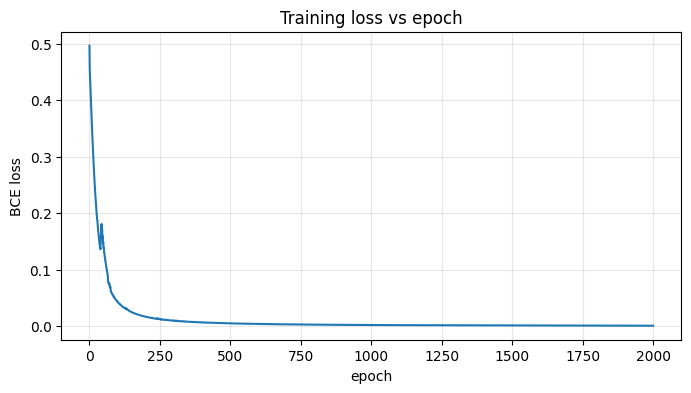

epoch    0   loss = 0.4967
epoch   50   loss = 0.1383
epoch  200   loss = 0.0168
epoch 1000   loss = 0.0023
epoch 1999   loss = 0.0010


In [ ]:
def train(X, y, W1, b1, W2, b2, epochs, lr_fn):
    losses = []
    for t in range(epochs):
        Z1 = X @ W1 + b1
        A1 = relu(Z1)
        Z2 = A1 @ W2 + b2
        A2 = sigmoid(Z2)
        losses.append(bce(y, A2))

        N = X.shape[0]
        dZ2 = (A2 - y) / N
        dW2 = A1.T @ dZ2
        db2 = dZ2.sum(axis=0, keepdims=True)
        dA1 = dZ2 @ W2.T
        dZ1 = dA1 * relu_grad(Z1)
        dW1 = X.T @ dZ1
        db1 = dZ1.sum(axis=0, keepdims=True)

        lr = lr_fn(t)
        W1 -= lr * dW1; b1 -= lr * db1
        W2 -= lr * dW2; b2 -= lr * db2
    return W1, b1, W2, b2, losses

W1t, b1t, W2t, b2t, losses = train(
    X, y, W1.copy(), b1.copy(), W2.copy(), b2.copy(),
    epochs=2000, lr_fn=lambda t: 1.0,
)

plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('epoch'); plt.ylabel('BCE loss')
plt.title('Training loss vs epoch')
plt.grid(alpha=0.3)
plt.show()

for ep in [0, 50, 200, 1000, 1999]:
    print(f'epoch {ep:>4}   loss = {losses[ep]:.4f}')

BP:how much loss is affecting weight-gives gradient; Optimiser:understnads gradient and increase the weight and rerun it

In [ ]:
Z1 = X @ W1t + b1t; A1 = relu(Z1)
Z2 = A1 @ W2t + b2t; A2 = sigmoid(Z2)
final = pd.DataFrame({
    'P(buy)': A2.flatten().round(4),
    'pred':   (A2 >= 0.5).astype(int).flatten(),
    'true':   y.flatten().astype(int),
}, index=ROW_NAMES)
final['correct?'] = np.where(final['pred'] == final['true'], 'YES', 'no')
final
#prediction after BP

,P(buy),pred,true,correct?
A,0.0020,0,0,YES
B,0.9988,1,1,YES
C,1.0000,1,1,YES
D,0.0020,0,0,YES
E,1.0000,1,1,YES


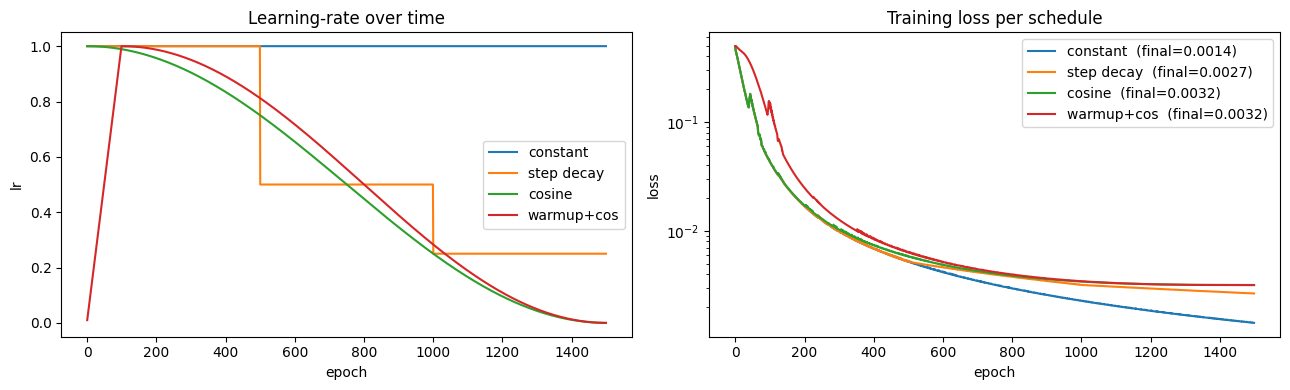

In [24]:
epochs = 1500
lr0 = 1.0

schedules = {
    'constant':    lambda t: lr0,
    'step decay':  lambda t: lr0 * (0.5 ** (t // 500)),
    'cosine':      lambda t: 0.5 * lr0 * (1 + np.cos(np.pi * t / epochs)),
    'warmup+cos':  lambda t: (lr0 * (t + 1) / 100) if t < 100
                             else 0.5 * lr0 * (1 + np.cos(np.pi * (t - 100) / (epochs - 100))),
}

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4))

for name, fn in schedules.items():
    lrs = [fn(t) for t in range(epochs)]
    ax1.plot(lrs, label=name)
    _, _, _, _, sched_losses = train(
        X, y, W1.copy(), b1.copy(), W2.copy(), b2.copy(), epochs, fn,
    )
    ax2.plot(sched_losses, label=f'{name}  (final={sched_losses[-1]:.4f})')

ax1.set_title('Learning-rate over time'); ax1.set_xlabel('epoch'); ax1.set_ylabel('lr'); ax1.legend()
ax2.set_title('Training loss per schedule'); ax2.set_xlabel('epoch'); ax2.set_ylabel('loss'); ax2.set_yscale('log'); ax2.legend()
plt.tight_layout()
plt.show()

In [23]:
print('INITIAL W1 (what we hand-picked):')
display(pd.DataFrame(W1, index=FEATURE_NAMES, columns=HIDDEN_NAMES).round(4))

print('TRAINED W1 (what the network ended up with):')
display(pd.DataFrame(W1t, index=FEATURE_NAMES, columns=HIDDEN_NAMES).round(4))

print('Delta (trained - initial):')
display(pd.DataFrame(W1t - W1, index=FEATURE_NAMES, columns=HIDDEN_NAMES).round(4))

#training based weight iteration 

INITIAL W1 (what we hand-picked):


,wealth,maturity,urgency
age,0.5,1.0,0.2
salary,1.5,0.3,0.8


TRAINED W1 (what the network ended up with):


,wealth,maturity,urgency
age,-1.1427,0.8515,-0.7542
salary,6.8270,0.5070,4.5070


Delta (trained - initial):


,wealth,maturity,urgency
age,-1.6427,-0.1485,-0.9542
salary,5.3270,0.2070,3.7070
